<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/2%E1%84%8C%E1%85%A1%E1%86%BC_%E1%84%8B%E1%85%B5%E1%84%89%E1%85%A1%E1%86%AB%E1%84%89%E1%85%B5%E1%86%AB%E1%84%92%E1%85%A9%E1%84%8B%E1%85%B4_%E1%84%8B%E1%85%A7%E1%86%AB%E1%84%89%E1%85%A1%E1%86%AB%E1%84%80%E1%85%AA_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2장. 이산신호의 연산과 분류
## Operations and Classification of Discrete-Time Signals



> 대응 주차: 2주차 (이산신호와 시스템)
> 대응 교재: 『파이썬으로 배우는 디지털 신호처리 — 생체신호 응용까지』

---

**실행 환경 안내**

본 노트북은 Google Colab에서 바로 실행할 수 있도록 작성되었다. 별도의 설치 과정 없이 위의 배지를 클릭하면 즉시 실행 환경이 열린다.


In [2]:
# 필요 라이브러리 확인 (Colab에는 기본적으로 설치되어 있음)
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

print("numpy version:", np.__version__)


numpy version: 2.0.2


---

## 2.0 개요 (Overview)

1장에서는 연속신호 $x(t)$와 이산신호 $x[n]$의 관계를 정의하고, 표본화를 통해 하나가 다른 하나로부터 어떻게 도출되는지를 살펴보았다. 또한 시스템을 입력과 출력을 연결하는 연산자 $T[\cdot]$로 정의하면서, 그 구체적인 성질(선형성, 시불변성, 인과성, 안정성)은 2장에서 본격적으로 다루겠다고 예고하였다.

2장에서는 두 가지 축을 따라 내용을 전개한다.

- 첫째, 이산신호 자체에 적용할 수 있는 기본 연산(시간이동, 시간반전, 척도변환 등)과 분류 기준(주기성, 에너지/전력, 짝/홀)을 정리한다.
- 둘째, 시스템이 갖출 수 있는 네 가지 핵심 성질을 정의하고, 각 성질을 만족하거나 위반하는 구체적인 예시 시스템을 통해 직관을 확립한다.

이 두 축은 3장(컨볼루션)에서 선형 시불변(LTI) 시스템의 입출력 관계를 다룰 때 반드시 필요한 사전 지식에 해당한다.


---

## 2.1 이산신호의 기본 연산 (Basic Operations on Discrete-Time Signals)

이산신호 $x[n]$에 적용할 수 있는 연산은, 복잡한 신호를 단순한 신호들의 조합으로 분해하거나 합성하기 위한 도구로 사용된다.

### 2.1.1 시간이동 (Time Shifting)

$$
y[n] = x[n-n_0] \tag{2.1}
$$

$n_0 > 0$이면 신호가 시간축 상에서 오른쪽으로 이동하며, 이를 지연(delay)이라 부른다. $n_0 < 0$이면 왼쪽으로 이동하며, 이를 전진(advance)이라 부른다.

### 2.1.2 시간반전 (Time Reversal)

$$
y[n] = x[-n] \tag{2.2}
$$

신호의 그래프를 인덱스 $n=0$을 기준으로 좌우로 뒤집은 것에 해당한다. 이 연산은 2.2.3절의 짝신호/홀신호 분해와 3장의 컨볼루션 연산을 이해하는 데 필수적인 사전 도구이다.

### 2.1.3 진폭 척도변환 (Amplitude Scaling)

$$
y[n] = a \cdot x[n], \qquad a \in \mathbb{R} \tag{2.3}
$$

신호의 크기(세로축 방향)만을 $a$배로 조정하는 연산이며, 인덱스 $n$ 자체는 변하지 않는다.

### 2.1.4 신호의 합과 곱 (Addition and Multiplication of Signals)

두 신호 $x_1[n]$, $x_2[n]$에 대하여, 동일한 인덱스 $n$에서의 값끼리 연산을 수행한다.

$$
y[n] = x_1[n] + x_2[n], \qquad y[n] = x_1[n] \cdot x_2[n] \tag{2.4}
$$

이를 각 점에서의 연산(pointwise operation)이라 부르며, 신호 전체를 하나의 벡터로 간주했을 때 벡터의 원소별(element-wise) 연산과 정확히 일치한다.

### 2.1.5 시간축 척도변환 (Time Scaling): 이산신호만의 특수성

연속신호의 시간축 척도변환 $x(at)$는 $a$가 어떤 실수이든 수학적으로 항상 잘 정의된다. 그러나 이산신호의 경우, 인덱스 $n$은 반드시 정수여야 하므로 $x[an]$이라는 표현은 $a$가 정수가 아닐 때 곧바로 정의되지 않는다는 근본적인 차이가 발생한다.

- **데시메이션(decimation, 다운샘플링)** $y[n] = x[Mn]$ ($M$은 양의 정수): 원신호에서 $M$개 표본마다 하나씩만 취하는 연산이며, 정보의 일부가 버려진다.  
- **인터폴레이션(interpolation, 업샘플링)**은 $x[n/L]$ ($L$은 양의 정수)을 $n$이 $L$의 배수인 위치에서만 정의하고, 그 사이의 값은 보간(interpolation)을 통해 새로 만들어 채워야 한다.

> 이 특수성은 신호처리 전체에서 반복적으로 등장하는 중요한 주제이며, 다중률 신호처리(multirate signal processing)라는 별도의 분야로 발전한다. 본 교재에서는 개념적 소개 수준으로 제한하며, 구체적인 구현은 다루지 않는다.


---

## 2.2 이산신호의 분류 (Classification of Discrete-Time Signals)

### 2.2.1 주기신호와 비주기신호 (Periodic and Aperiodic Signals)

이산신호 $x[n]$이 주기신호(periodic signal)라는 것은, 어떤 양의 정수 $N$이 존재하여 모든 $n$에 대하여

$$
x[n] = x[n+N] \tag{2.5}
$$

이 성립함을 의미한다. 이를 만족하는 가장 작은 양의 정수 $N$을 기본주기(fundamental period)라 부른다.

이산시간 정현파 $x[n] = A\cos(\Omega_0 n + \phi)$의 주기성을 따져보면, 연속신호에는 없는 독특한 조건이 도출된다. $x[n+N] = x[n]$이 성립하려면

$$
\cos\big(\Omega_0(n+N) + \phi\big) = \cos(\Omega_0 n + \phi) \quad \text{(모든 } n\text{에 대하여)} \tag{2.6}
$$

이어야 하며, 이는 $\Omega_0 N$이 $2\pi$의 정수배일 때, 즉 어떤 정수 $k$가 존재하여

$$
\Omega_0 N = 2\pi k \quad \Longleftrightarrow \quad \frac{\Omega_0}{2\pi} = \frac{k}{N} \tag{2.7}
$$

가 성립할 때에만 만족된다. 다시 말해, **이산시간 정현파가 주기신호가 되기 위한 필요충분조건은 $\Omega_0/2\pi$가 유리수(rational number)여야 한다는 것**이다. 연속시간 정현파는 $\omega_0$가 어떤 실수이든 항상 주기신호이지만, 이산시간 정현파는 $\Omega_0/2\pi$가 무리수이면 비주기신호가 된다.

**수치 예시**: 1장 1.3.3절에서 다룬 $f_0 = 5$ Hz, $f_s = 50$ Hz의 예시를 다시 살펴보면, $\Omega_0 = \pi/5$이므로

$$
\frac{\Omega_0}{2\pi} = \frac{\pi/5}{2\pi} = \frac{1}{10} \tag{2.8}
$$

는 유리수이며, $k=1$, $N=10$에 대응하므로 이 신호는 기본주기 $N=10$인 주기신호이다. 반면 $\Omega_0 = 1$ rad/sample인 정현파는 $\Omega_0/2\pi = 1/(2\pi)$가 무리수이므로 비주기신호이다.

### 2.2.2 에너지신호와 전력신호 (Energy Signals and Power Signals)

이산신호의 에너지와 전력은 연속신호의 적분을 합(summation)으로 바꾸어 정의한다.

$$
E_x = \sum_{n=-\infty}^{\infty} \lvert x[n] \rvert^2, \qquad P_x = \lim_{N\to\infty} \frac{1}{2N+1}\sum_{n=-N}^{N} \lvert x[n] \rvert^2 \tag{2.9}
$$

$E_x$가 유한한 양의 값이면 에너지신호(energy signal), $E_x$가 무한대이면서 $P_x$가 유한한 양의 값이면 전력신호(power signal)로 분류한다. 이산시간 정현파 $x[n] = A\cos(\Omega_0 n + \phi)$는 영원히 지속되는 신호이므로 $E_x = \infty$이지만, 평균전력은 $P_x = A^2/2$로 유한하므로 전형적인 전력신호에 해당한다.

### 2.2.3 짝신호와 홀신호, 그리고 짝-홀 분해 (Even and Odd Signals, and Even-Odd Decomposition)

**(1) 정의와 직관적 의미**

$$
x[-n] = x[n] \;\Rightarrow\; \text{짝신호(even signal)}, \qquad x[-n] = -x[n] \;\Rightarrow\; \text{홀신호(odd signal)} \tag{2.10}
$$

짝신호는 신호의 그래프를 세로축($n=0$을 지나는 수직선)을 기준으로 좌우로 접었을 때 완전히 겹쳐지는 신호이며, 거울에 비친 모습과 자기 자신이 동일한 경우에 해당한다. 반대로 홀신호는 원점을 기준으로 $180^\circ$ 회전시켰을 때(즉 좌우로 뒤집은 뒤 위아래로도 뒤집었을 때) 자기 자신과 겹쳐지는 신호이다.

홀신호가 가지는 중요한 성질 하나는, $n=0$에서의 값이 반드시 0이어야 한다는 것이다. 정의 $x[-n]=-x[n]$에 $n=0$을 대입하면 $x[0] = -x[0]$이 되며, 이를 만족하는 값은 $x[0]=0$ 뿐이기 때문이다. 반면 짝신호는 $x[0]$이 0이어야 한다는 제약이 없다.

**(2) 대표적인 예시**

| 신호 $x[n]$ | 분류 | 판별 근거 |
|---|---|---|
| $x[n] = c$ (상수) | 짝신호 | $x[-n]=c=x[n]$이 항상 성립 |
| $x[n] = n$ | 홀신호 | $x[-n]=-n=-x[n]$ |
| $x[n] = n^2$ | 짝신호 | $x[-n]=(-n)^2=n^2=x[n]$ |
| $x[n] = \cos(\Omega_0 n)$ | 짝신호 | $\cos(\cdot)$는 우함수이므로 $\cos(-\Omega_0 n)=\cos(\Omega_0 n)$ |
| $x[n] = \sin(\Omega_0 n)$ | 홀신호 | $\sin(\cdot)$는 기함수이므로 $\sin(-\Omega_0 n)=-\sin(\Omega_0 n)$ |
| $x[n] = u[n]$ <br>(단위계단) | 둘 다 아님 | $x[-n]$이 $x[n]$과도, $-x[n]$과도 같지 않음 (예: $n=1$에서 $x[1]=1$, $x[-1]=0$) |
| $x[n] = a^n u[n]$ <br>(인과적 지수신호) | 둘 다 아님 | $n<0$에서는 $0$이지만 $n\geq0$에서는 $0$이 아니므로 좌우 대칭/점대칭 어느 쪽도 성립하지 않음 |

이 표에서 볼 수 있듯, **신호는 반드시 짝신호 또는 홀신호 중 하나로 분류되어야 하는 것은 아니며**, 단위계단이나 인과적 지수신호처럼 둘 중 어느 것에도 속하지 않는 경우가 오히려 더 일반적이다. 바로 이 점 때문에 다음에서 다루는 짝-홀 분해가 유용한 도구가 된다.

**(3) 짝-홀 분해 (Even-Odd Decomposition)**

임의의 신호 $x[n]$이 짝신호나 홀신호가 아니더라도, 다음과 같이 짝신호 성분 $x_e[n]$과 홀신호 성분 $x_o[n]$의 합으로는 항상 분해할 수 있다.

$$
x_e[n] = \frac{x[n] + x[-n]}{2}, \qquad x_o[n] = \frac{x[n] - x[-n]}{2}, \qquad x[n] = x_e[n] + x_o[n] \tag{2.11}
$$

이 분해가 항상 가능함은 $x_e[n]+x_o[n] = x[n]$이 정의에 의해 자명하게 성립하고, $x_e[-n] = \big(x[-n]+x[n]\big)/2 = x_e[n]$, $x_o[-n] = \big(x[-n]-x[n]\big)/2 = -x_o[n]$이 성립하여 각각 짝신호와 홀신호의 정의를 만족함으로써 증명된다.

**(4) 수치 예시를 통한 검증**

$n=-2,\dots,2$ 구간에서 정의된 신호 $x[n] = n+3$을 예로 들어, 분해 공식이 실제로 어떻게 동작하는지 직접 손으로 계산해 보자.

| $n$ | $x[n]=n+3$ | $x[-n]$ | $x_e[n]=\dfrac{x[n]+x[-n]}{2}$ | $x_o[n]=\dfrac{x[n]-x[-n]}{2}$ |
|---|---|---|---|---|
| $-2$ | $1$ | $5$ | $3$ | $-2$ |
| $-1$ | $2$ | $4$ | $3$ | $-1$ |
| $0$ | $3$ | $3$ | $3$ | $0$ |
| $1$ | $4$ | $2$ | $3$ | $1$ |
| $2$ | $5$ | $1$ | $3$ | $2$ |

계산 결과 $x_e[n] = 3$ (모든 $n$에서 일정한 상수, 짝신호)이고 $x_o[n] = n$ (홀신호)임이 확인되며, $x_e[n]+x_o[n] = 3+n = x[n]$이 정확히 성립한다. 이 예시는 $x[n]=n+3$이라는 1차식이, 상수항(짝신호 성분)과 1차항(홀신호 성분)으로 정확히 분리되는 모습을 보여준다. 또한 $x_o[0]=0$으로, 앞서 (1)항에서 설명한 "홀신호는 $n=0$에서 항상 0이다"라는 성질도 함께 확인할 수 있다.

> **참고**: 짝-홀 분해는 5장(연속신호의 푸리에 급수/변환)에서 다시 중요하게 등장한다. 신호의 짝신호 성분은 코사인(cosine) 항들로만, 홀신호 성분은 사인(sine) 항들로만 구성된 푸리에 급수로 표현된다는 사실이 알려져 있으며, 이는 본 절에서 다룬 분해가 단순한 수학적 트릭이 아니라 주파수 영역 해석의 구조와 직접 연결되는 개념임을 보여준다.


---

## 2.3 이산 시스템의 정의와 분류 (Definition and Classification of Discrete-Time Systems)

1장 1.2절에서 정의한 시스템 연산자 $T[\cdot]$를 이산신호에 그대로 적용하면 다음과 같다.

$$
y[n] = T[x[n]] \tag{2.12}
$$

이산 시스템은 출력이 입력의 어느 시점 값에 의존하는가에 따라 다음과 같이 구분된다.

- **무기억 시스템(memoryless system)**: 출력 $y[n]$이 동일한 시점 $n$의 입력 $x[n]$에만 의존하는 시스템이다 (예: $y[n] = x[n]^2$).
- **기억 시스템(system with memory)**: 출력 $y[n]$이 현재뿐만 아니라 과거 또는 미래의 입력값에도 의존하는 시스템이다 (예: $y[n] = x[n] + x[n-1]$).

이 구분은 2.4절에서 다룰 인과성(causality)의 개념과 밀접하게 연결된다.


---

## 2.4 이산 시스템의 주요 성질 (Key Properties of Discrete-Time Systems)

아래에서 정의하는 네 가지 성질은 디지털 신호처리 전반에서 표준적으로 사용되는 정의를 따른다.

### 2.4.1 선형성 (Linearity)

시스템 $T[\cdot]$가 선형(linear)이라는 것은, 임의의 두 입력 $x_1[n]$, $x_2[n]$과 임의의 스칼라 $a$, $b$에 대하여 다음의 중첩의 원리(superposition principle)가 성립함을 의미한다.

$$
T\big[a\,x_1[n] + b\,x_2[n]\big] = a\,T\big[x_1[n]\big] + b\,T\big[x_2[n]\big] \tag{2.13}
$$

이 성질은 가산성(additivity, $a=b=1$인 경우)과 균일성(homogeneity, $x_2=0$인 경우)으로 분리하여 점검할 수도 있다.

### 2.4.2 시불변성 (Time-Invariance)

시스템이 시불변(time-invariant)이라는 것은, 입력이 시간적으로 이동하면 출력도 동일한 양만큼 그대로 이동할 뿐, 시스템의 동작 방식 자체는 변하지 않음을 의미한다. 즉, $x[n] \xrightarrow{T} y[n]$일 때 임의의 정수 $n_0$에 대하여

$$
x[n-n_0] \xrightarrow{T} y[n-n_0] \tag{2.14}
$$

이 성립하면 시불변 시스템이다.

### 2.4.3 인과성 (Causality)

시스템이 인과적(causal)이라는 것은, 출력 $y[n]$이 시점 $n$ 또는 그 이전의 입력값들($x[n], x[n-1], x[n-2], \dots$)에만 의존하며, 아직 도착하지 않은 미래의 입력($x[n+1], x[n+2], \dots$)에는 의존하지 않음을 의미한다. 실시간으로 동작해야 하는 물리적 시스템은 반드시 인과적이어야 한다.

### 2.4.4 안정성 (Stability, BIBO Stability)

시스템이 유계입력 유계출력(BIBO, Bounded-Input Bounded-Output) 의미에서 안정(stable)하다는 것은, 입력이 어떤 유한한 값으로 항상 제한되어 있으면($\lvert x[n]\rvert \le B_x < \infty$, 모든 $n$에 대하여) 출력 역시 항상 유한한 값으로 제한됨을 의미한다.

$$
\lvert x[n] \rvert \le B_x \;(\forall n) \quad \Longrightarrow \quad \lvert y[n] \rvert \le B_y < \infty \;(\forall n) \tag{2.15}
$$

### 2.4.5 종합 예시 (Summary of Examples)

아래 표는 대표적인 시스템들이 네 가지 성질을 만족하는지를 정리한 것이다.

| 시스템 | 선형성 | 시불변성 | 인과성 | 안정성 |
|---|---|---|---|---|
| $y[n] = 2x[n]$ | 만족 | 만족 | 만족 | 만족 |
| $y[n] = x[n] + 3$ | **위반** (덧셈상수로 중첩의 원리 깨짐) | 만족 | 만족 | 만족 |
| $y[n] = x[n]^2$ | **위반** (비선형) | 만족 | 만족 | 만족 (유계입력이면 유계출력) |
| $y[n] = x[n-1]$ | 만족 | 만족 | 만족 | 만족 |
| $y[n] = x[n+1]$ | 만족 | 만족 | **위반** (미래값 필요) | 만족 |
| $y[n] = n\,x[n]$ | 만족 | **위반** ($n$이라는 절대적 시간기준 사용) | 만족 | **위반** ($x[n]=1$이면 $y[n]=n \to \infty$) |
| $y[n] = \displaystyle\sum_{k=-\infty}^{n} x[k]$ (누적기, accumulator) | 만족 | 만족 | 만족 | **위반** ($x[n]=u[n]$이면 $y[n]=(n+1)u[n] \to \infty$) |

이 표에서 누적기(accumulator)와 $y[n]=n\,x[n]$이 불안정한 이유는, 둘 다 유계입력(예: 항상 1의 값을 갖는 신호)에 대해 출력이 시간이 지남에 따라 무한히 커지기 때문이다. 이 두 예시는 4장 이후 z변환을 이용한 안정성 판별(단위원 내부의 극점 조건)을 학습할 때 다시 등장하는 중요한 사전 사례에 해당한다.


---

## 2.5 핵심 알고리즘: 선형성과 시불변성의 수치적 검증 (Core Algorithm: Numerical Verification of Linearity and Time-Invariance)

$$
\begin{array}{ll}
\textbf{Algorithm 2.1} & \text{선형성과 시불변성의 수치적 검증 (Numerical verification of linearity and time-invariance)} \\[6pt]
\textbf{Require:} & T[\cdot] \text{ (검증할 시스템 연산자)},\ x_1[n],\,x_2[n] \text{ (테스트 입력신호)},\ a,\,b \text{ (중첩 계수)},\ n_0 \text{ (시간이동량)} \\
\textbf{Ensure:} & \text{linearity\_ok},\ \text{time\_invariance\_ok} \text{ (부울값)} \\[6pt]
1: & y_1[n] \leftarrow T[x_1[n]] \\
2: & y_2[n] \leftarrow T[x_2[n]] \\
3: & y_{\text{super}}[n] \leftarrow T\big[a\,x_1[n] + b\,x_2[n]\big] \\
4: & y_{\text{comb}}[n] \leftarrow a\,y_1[n] + b\,y_2[n] \\
5: & \text{linearity_ok} \leftarrow \big(y_{\text{super}}[n] \approx y_{\text{comb}}[n],\ \forall n\big) \\
6: & x_{1,\text{shift}}[n] \leftarrow x_1[n - n_0] \\
7: & y_{\text{shift-in}}[n] \leftarrow T\big[x_{1,\text{shift}}[n]\big] \\
8: & y_{\text{shift-out}}[n] \leftarrow y_1[n - n_0] \\
9: & \text{time_invariance_ok} \leftarrow \big(y_{\text{shift-in}}[n] \approx y_{\text{shift-out}}[n],\ \forall n\big) \\
10: & \textbf{return } \text{linearity_ok},\ \text{time_invariance_ok}
\end{array}
$$

이 알고리즘은 시스템의 선형성과 시불변성을 수식으로 증명하는 대신, 임의로 선택한 두 테스트 신호에 대하여 정의를 그대로 수치적으로 검증하는 방식을 취한다. 다만 주의할 점은, 이 알고리즘이 특정 테스트 신호들에 대해서 성질을 만족함을 보여줄 뿐, 모든 가능한 입력에 대한 일반적인 증명을 대체하지는 않는다는 것이다. 즉, 수치적 검증은 "반례를 찾아 성질이 위반됨을 보이는 것"에는 유용하지만, "모든 경우에 성립함을 보이는 것"에는 한계가 있다. 엄밀한 증명은 항상 해석적(analytic) 방법으로 별도로 수행되어야 한다.

- **1~2행**: 두 테스트 입력 $x_1[n]$, $x_2[n]$을 각각 시스템에 통과시켜 개별 출력 $y_1[n]$, $y_2[n]$을 얻는다.
- **3~5행**: 중첩된 입력 $a x_1[n]+b x_2[n]$을 시스템에 직접 통과시킨 결과($y_{\text{super}}$)와, 개별 출력을 먼저 구한 뒤 중첩한 결과($y_{\text{comb}}$)를 비교하여 선형성을 판별한다.
- **6~9행**: 입력을 먼저 이동시킨 뒤 시스템에 통과시킨 결과($y_{\text{shift-in}}$)와, 시스템을 통과시킨 뒤 출력을 이동시킨 결과($y_{\text{shift-out}}$)를 비교하여 시불변성을 판별한다.


---

## 2.6 파이썬 구현 (Python Implementation)

아래 코드는 다섯 개의 셀로 나누어 구성하였다. 순서대로
① 시간이동/시간반전 함수,    
② 짝-홀 분해 함수,    
③ 주기성 판별 함수,    
④ 선형성/시불변성 검증 함수,    
⑤ 실행 및 시각화부이다.   
**결과를 미리 포함하지 않았으므로, 아래 셀들을 순서대로 직접 실행하여 결과를 확인하기 바란다.**


In [3]:
"""
2장 예제: 이산신호의 기본 연산(시간이동, 시간반전, 짝-홀 분해), 주기성 판별,
그리고 시스템의 선형성/시불변성에 대한 수치적 검증을 구현한다.
필요 라이브러리: numpy, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction


def shift_signal(n: np.ndarray, x: np.ndarray, n0: int) -> np.ndarray:
    """
    이산신호 x[n]을 n0만큼 시간이동(time shift)한 y[n] = x[n - n0]를 반환한다.
    동일한 인덱스 벡터 n 위에서 결과를 표현하기 위해, 이동으로 인해 벗어나는
    구간은 0으로 채운다(zero padding).
    """
    y = np.zeros_like(x, dtype=float)
    n_to_pos = {ni: i for i, ni in enumerate(n)}
    for i, ni in enumerate(n):
        src = n_to_pos.get(ni - n0)
        if src is not None:
            y[i] = x[src]
    return y


def reflect_signal(n: np.ndarray, x: np.ndarray) -> np.ndarray:
    """이산신호 x[n]을 시간반전(time reversal)한 y[n] = x[-n]를 반환한다."""
    y = np.zeros_like(x, dtype=float)
    n_to_pos = {ni: i for i, ni in enumerate(n)}
    for i, ni in enumerate(n):
        src = n_to_pos.get(-ni)
        if src is not None:
            y[i] = x[src]
    return y


In [4]:
def even_odd_decomposition(n: np.ndarray, x: np.ndarray):
    """이산신호 x[n]을 짝신호 성분 x_e[n]과 홀신호 성분 x_o[n]으로 분해한다."""
    x_reflected = reflect_signal(n, x)
    x_even = 0.5 * (x + x_reflected)
    x_odd = 0.5 * (x - x_reflected)
    return x_even, x_odd


In [5]:
def is_periodic_discrete_sinusoid(Omega0: float, max_denominator: int = 1000):
    """
    이산시간 정현파 x[n] = A*cos(Omega0*n + phi)의 주기성 여부를 판별한다.
    Omega0 / (2*pi)가 유리수이면 주기신호이며, 그 유리수의 분모가 기본주기 N이 된다.
    """
    ratio = Omega0 / (2 * np.pi)
    frac = Fraction(ratio).limit_denominator(max_denominator)
    is_periodic = abs(float(frac) - ratio) < 1e-9
    fundamental_period = frac.denominator if is_periodic else None
    return is_periodic, fundamental_period


In [6]:
def verify_linearity_and_time_invariance(system_func, n: np.ndarray,
                                          x1: np.ndarray, x2: np.ndarray,
                                          a: float, b: float, n0: int,
                                          tol: float = 1e-9):
    """
    주어진 시스템 system_func(n, x) -> y 에 대하여 선형성과 시불변성을
    Algorithm 2.1의 절차에 따라 수치적으로 검증한다.
    """
    y1 = system_func(n, x1)

    x_super = a * x1 + b * x2
    y_super = system_func(n, x_super)
    y_combined = a * y1 + b * system_func(n, x2)
    linearity_ok = bool(np.allclose(y_super, y_combined, atol=tol))

    x1_shifted = shift_signal(n, x1, n0)
    y_shift_in = system_func(n, x1_shifted)
    y_shift_out = shift_signal(n, y1, n0)
    time_invariance_ok = bool(np.allclose(y_shift_in, y_shift_out, atol=tol))

    return linearity_ok, time_invariance_ok


Omega0 = pi/5 인 정현파 -> 주기신호 여부: True, 기본주기 N = 10
[지연 시스템 y[n]=x[n-1]] 선형성: True, 시불변성: True
[제곱 시스템 y[n]=x[n]^2 ] 선형성: False, 시불변성: True


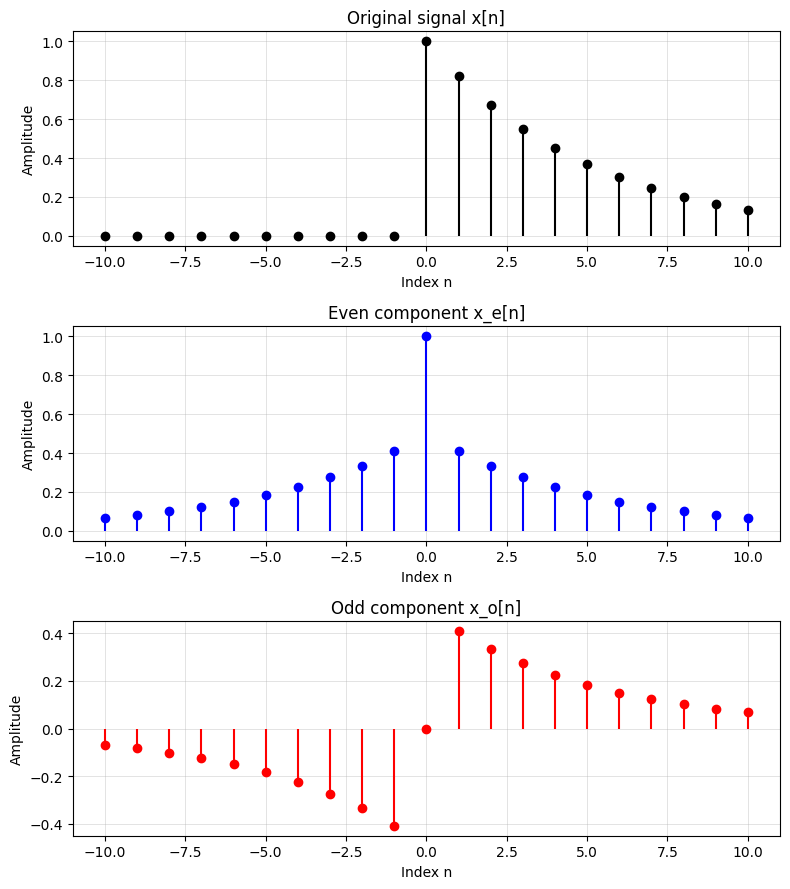

In [7]:
# 실행부
n = np.arange(-10, 11)

# 테스트 신호 1: 인과적 지수형 신호, 테스트 신호 2: 이산 정현파
x1 = np.where(n >= 0, 1.0, 0.0) * np.exp(-0.2 * np.maximum(n, 0))
x2 = np.cos(2 * np.pi * n / 8.0)

# (1) 짝-홀 분해
x_even, x_odd = even_odd_decomposition(n, x1)

# (2) 주기성 판별: 1장의 예시(Omega0 = pi/5)를 재사용
Omega0_example = np.pi / 5
periodic, N0 = is_periodic_discrete_sinusoid(Omega0_example)
print(f"Omega0 = pi/5 인 정현파 -> 주기신호 여부: {periodic}, 기본주기 N = {N0}")

# (3) 시스템 정의: 지연 시스템(선형/시불변)과 제곱 시스템(비선형)
def system_delay(n, x):
    return shift_signal(n, x, 1)

def system_square(n, x):
    return x ** 2

lin_delay, ti_delay = verify_linearity_and_time_invariance(
    system_delay, n, x1, x2, a=2.0, b=-1.5, n0=3
)
lin_square, ti_square = verify_linearity_and_time_invariance(
    system_square, n, x1, x2, a=2.0, b=-1.5, n0=3
)

print(f"[지연 시스템 y[n]=x[n-1]] 선형성: {lin_delay}, 시불변성: {ti_delay}")
print(f"[제곱 시스템 y[n]=x[n]^2 ] 선형성: {lin_square}, 시불변성: {ti_square}")

# (4) 시각화
fig, axes = plt.subplots(3, 1, figsize=(8, 9), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

axes[0].stem(n, x1, linefmt='k-', markerfmt='ko', basefmt=' ')
axes[0].set_title('Original signal x[n]')
axes[0].set_xlabel('Index n')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, linewidth=0.5, alpha=0.5)

axes[1].stem(n, x_even, linefmt='b-', markerfmt='bo', basefmt=' ')
axes[1].set_title('Even component x_e[n]')
axes[1].set_xlabel('Index n')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, linewidth=0.5, alpha=0.5)

axes[2].stem(n, x_odd, linefmt='r-', markerfmt='ro', basefmt=' ')
axes[2].set_title('Odd component x_o[n]')
axes[2].set_xlabel('Index n')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, linewidth=0.5, alpha=0.5)

fig.tight_layout()
plt.show()


### 코드 해설

1. **`shift_signal`, `reflect_signal`**: 두 함수 모두 동일한 패턴을 따른다. 유한한 길이의 배열로 표현된 이산신호는 인덱스 범위를 벗어나는 부분을 정의할 수 없으므로, 딕셔너리 `n_to_pos`를 이용하여 "원하는 인덱스가 현재 배열의 범위 안에 존재하는가"를 먼저 확인하고, 존재하지 않으면 0으로 채우는 영 채움(zero padding) 방식을 일관되게 적용하였다.
2. **`even_odd_decomposition`**: 식 (2.11)의 $x_e[n]=(x[n]+x[-n])/2$, $x_o[n]=(x[n]-x[-n])/2$을 그대로 구현한 것이며, 별도의 반복문 없이 `reflect_signal`이 반환한 배열에 대한 벡터 연산만으로 처리된다.
3. **`is_periodic_discrete_sinusoid`**: 표준 라이브러리 `fractions.Fraction`의 `limit_denominator` 메서드를 이용하여, 부동소수점으로 표현된 비율 $\Omega_0/2\pi$에 가장 근접한 유리수(분모가 `max_denominator` 이하인 것 중 최선의 근사)를 찾는다. 이렇게 찾은 유리수가 원래의 비율과 충분히 가까우면(부동소수점 오차 허용) 유리수로 판정하고, 그 분모를 기본주기 $N$으로 반환한다.
4. **`verify_linearity_and_time_invariance`**: Algorithm 2.1의 1~9행을 그대로 함수로 옮긴 것이다. `system_func`라는 매개변수에 임의의 시스템 함수를 전달할 수 있도록 설계하여, 이후 3장 이후의 다양한 시스템(컨볼루션 기반 시스템 등)에 대해서도 동일한 검증 함수를 재사용할 수 있다.
5. **실행부**: 지연 시스템(`system_delay`)과 제곱 시스템(`system_square`) 두 가지를 정의하여 검증 함수에 통과시킨다. 지연 시스템은 선형성과 시불변성을 모두 만족해야 하고(`True, True`가 출력되어야 함), 제곱 시스템은 시불변성은 만족하지만 선형성은 위반해야 한다(`False, True`가 출력되어야 함). 이 예상 결과와 실제 실행 결과가 일치하는지 확인하는 것이, 검증 함수 자체의 정확성을 점검하는 좋은 습관이 된다.

여기서 강조해야 할 점은, 짝-홀 분해가 항상 가능한 반면, 시스템의 선형성/시불변성은 특정 테스트 신호에 대한 수치적 검증만으로는 반례를 찾는 데 유용할 뿐, 모든 입력에 대한 일반적 증명을 대체하지는 않는다는 것이다.


---

## 2.7 시각화와 해석 (Visualization and Interpretation)

위 코드를 실행하면 세 개의 부그래프(subplot)가 생성된다.

1. 원신호 $x[n]$: 인과적인 지수형 신호로, $n<0$에서는 0이고 $n\geq0$에서 지수적으로 감소한다.
2. 짝신호 성분 $x_e[n]$: 원신호와 그 시간반전 신호를 더한 후 2로 나눈 결과로, $n=0$을 기준으로 좌우 대칭인 형태를 보인다.
3. 홀신호 성분 $x_o[n]$: 원신호와 그 시간반전 신호를 뺀 후 2로 나눈 결과로, $n=0$을 기준으로 점대칭(위아래로 뒤집힌 대칭)인 형태를 보인다.

원신호가 인과적(즉, $n<0$에서 0)임에도 불구하고, 짝신호와 홀신호 성분은 시간반전 연산의 영향으로 $n<0$ 영역에서도 0이 아닌 값을 갖게 된다는 점이 중요한 관찰 포인트이다. 이는 짝-홀 분해가 신호의 인과성을 보존하지 않는다는 것을 보여주는 좋은 예시이며, 8장(z변환)에서 인과성과 신호의 구조 사이의 관계를 다시 다룰 때 참고할 수 있는 직관이다.

본 교재의 그래프 작성 원칙은 1장과 동일하게 유지된다.

- 그래프의 배경은 흰색으로 통일한다.
- 축 라벨(`Index n`, `Amplitude` 등)은 영어로 표기한다.
- 그래프 내 부가 설명은 한글로 병기한다.
- 색상은 신호의 구분이 필요한 최소한으로만 사용한다.

**실습 과제**: 위 실행부 셀에서 `n0`, `a`, `b` 값을 바꾸어 다시 실행해 보고, 지연 시스템과 제곱 시스템 각각에 대한 판별 결과가 여전히 이론적으로 예상한 대로 나오는지 확인하기 바란다.


---

## 2.8 응용 사례 (Application Case)

2.1절에서 정의한 시간이동 연산은, 생체신호 처리에서 흔히 등장하는 신호 정렬(alignment) 문제와 직접 연결된다. 예를 들어 여러 번 측정한 ECG(심전도) 박동 파형을 서로 겹쳐 평균을 내고자 할 때, 각 박동의 R파(R-wave) 정점 위치가 측정마다 조금씩 다르게 검출되므로, 이를 동일한 시간 기준점에 맞추기 위해 시간이동 연산이 사용된다. 다만 이러한 정렬 작업에 필요한 정점 검출이나 상호상관(cross-correlation) 기법은 3장의 컨볼루션 이론을 학습한 이후에 본격적으로 다룰 수 있으므로, 본 절에서는 개념적 연결만을 제시하며 구체적인 구현은 3장 말미의 응용 모듈 A(ECG 베이스라인 표류 검출)와 연계하여 다룬다.


---

## 2.9 연습문제 (예시) (Exercises, Examples)

**이론형**

1. 이산시간 정현파 $x[n] = \cos(0.3\pi n)$의 주기성 여부를 판별하고, 주기신호라면 기본주기 $N$을 구하라.
2. 시스템 $y[n] = x[n] \cdot x[n-1]$에 대하여 선형성, 시불변성, 인과성, 안정성을 각각 판별하고 그 근거를 서술하라.

**코딩형**

1. 아래 함수 시그니처를 완성하라.


In [8]:
def energy_and_power(x: np.ndarray) -> tuple:
    """
    유한 길이로 주어진 이산신호 x에 대하여,
    에너지 E_x = sum(|x[n]|^2)와
    평균전력 P_x = E_x / len(x) (유한 구간 근사)를 계산하여 반환한다.
    반환값: (E_x, P_x)
    """
    # TODO: 구현하시오.
    pass


2. `verify_linearity_and_time_invariance` 함수를 이용하여, 본문에서 다루지 않은 시스템 $y[n] = x[n] - x[n-2]$(이산 미분기, discrete differencer)에 대한 선형성과 시불변성을 검증하고, 그 결과가 이론적으로 예상한 결과와 일치하는지 서술하라.


In [9]:
# TODO: system_diff(n, x) = x[n] - x[n-2] 형태로 시스템 함수를 정의하고,
# verify_linearity_and_time_invariance를 호출하여 결과를 확인하시오.


---

## 참고문헌 (References)

1. Oppenheim, A. V., & Willsky, A. S. (1996). *Signals and Systems* (2nd ed.). Prentice Hall.
2. Proakis, J. G., & Manolakis, D. G. (2006). *Digital Signal Processing: Principles, Algorithms, and Applications* (4th ed.). Prentice Hall.
3. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.

---

*본 노트북은 「파이썬으로 배우는 디지털 신호처리 — 생체신호 응용까지」 2장을 Google Colab 실행 환경에 맞추어 변환한 버전이다.*
